# Neural network estimating free energy for different membrane compositions
In this notebook we calculate the free energy of 7 different membrane compositions of IRE1 projected onto the dRMSD and train a neural network to predict these free energies based on the dRMSD and membrane properties estimated by a different neural network (see properties_nn.ipynb)

What is done in this notebook (summary):
- Retraing the committor of AIMMD runs 
- Calculating the free energies and generate dataset 
- Train RNN to estimate the free energies  

In [7]:
%load_ext autoreload
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 
import os
import sys
import torch
from pathlib import Path
from scipy.special import logit, expit
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import itertools
from tqdm import tqdm
import numpy as np
import glob
from sklearn.preprocessing import StandardScaler

sys.path.insert(1, f'../../functions')
from functions import pkl_load, pkl_save, mkdir
import free_energy_nn as free_energy_nn
import aimmd_analysis as aimmd_analysis
import committor_nn as committor_nn
import properties_nn as properties_nn
import utils as aimmd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Definitions

Here we define the path to the AIMMD runs

In [2]:
%autoreload

# Get all AIMMD directories for a system
SYSTEMS = aimmd_analysis.get_paths(f'../../systems/full_elastic_network/**/new_aimmd', key_index=-2, verbose=True)

keys of dictionary:

DOPC100
POPC100
POPE100
POPC90_CHOL10
DIPC80_CHOL20
POPC80_CHOL20
POPC70_CHOL30
POPC80_DIPC20
POPC50_DIPC50
POPC80_DOPC20
POPC60_DOPC40
POPC50_DOPC50
POPC40_DOPC60
POPC20_DOPC80
POPC80_CHOL10_DPPC10
POPC90_DPPC10
DIPC60_CHOL20_DPPC20
POPC80_POPE20
POPC50_POPE50


# Retrain committor NN

In this section we retrain the committor of the AIMMD runs using a new training procedure that has shown to produce a more accurate committor model. This is done to ensure that the training dataset has the most accurate free energies we can get.

## Setup

In [225]:
# chosen compositions
COMPOSITIONS            = ['POPC100',
                         'POPC90_CHOL10',
                         'POPC80_CHOL20',
                         'POPC70_CHOL30',
                         'POPC80_DOPC20',
                         'POPC50_DOPC50',
                         'POPC20_DOPC80']

network_parameters     = {'n_features': 3136,
                          'hidden_layers': [512, 512, 512],
                          'activation': [torch.nn.PReLU(512), torch.nn.PReLU(512), torch.nn.PReLU(512)],
                          'dropout': 0.1,
                          'batch_norm': False}

## Training

In [16]:
%autoreload

committors_folder = mkdir('../../notebook_files/free_energy_nn_paper/free_energy_nn/committors')

for composition in COMPOSITIONS:
    
    # import AIMMD params
    current_directory = os.getcwd() 
    os.chdir(SYSTEMS[composition])
    exec(open(Path(f'params.py'), 'r').read())
    os.chdir(current_directory)

    # Load pathensemble
    PATHENSEMBLE = aimmd_analysis.load_pathensemble(states_function,
                                           descriptors_function,
                                           values_function,
                                           directory=SYSTEMS[composition] / 'prun_cluster',
                                           verbose=False,
                                           use_aimmd=True)
    
    
    # Main Training
    network = committor_nn.Network(**network_parameters)
    network.to('cuda')
    losses, scales, selection_probabilities, results = aimmd_analysis.new_fit_function(network,
                                                                                PATHENSEMBLE,
                                                                                None,
                                                                                batch_size = pow(2, 15),
                                                                                epochs=2000,
                                                                                lr=1e-3,
                                                                                save_to=f'{committors_folder}/{composition}.h5',
                                                                                verbose=True)

Training: , Epoch=1999, Train loss=0.422, validation loss=0.422, best validation loss=0.402, scales=9.37                                    
Training: , Epoch=1999, Train loss=0.472, validation loss=0.472, best validation loss=0.407, scales=8.82                                    
Training: , Epoch=1999, Train loss=0.399, validation loss=0.399, best validation loss=0.382, scales=10.2                                    
Training: , Epoch=1999, Train loss=0.359, validation loss=0.359, best validation loss=0.356, scales=9.88                                    
Training: , Epoch=1999, Train loss=0.415, validation loss=0.415, best validation loss=0.412, scales=8.79                                    
Training: , Epoch=1999, Train loss=0.65, validation loss=0.65, best validation loss=0.428, scales=6.58                                      
Training: , Epoch=1999, Train loss=0.447, validation loss=0.447, best validation loss=0.432, scales=8.88                                    


# Generating the training data

In this section we calculate the free energies of 7 different membrane compositions using the new retrained committor models and create a dataset for training the neural network. To get a good exploration of the free energy surface of the dRMSD we calculated the free energy for each membrane composition four times while shifting the bins slightly.

## Setup

In [250]:
# Definitions
bin_shift = [[0, 4], [0.01, 4.01], [0.02, 4.02], [0.03, 4.03], [0.04, 4.04], [0.05, 4.05], [0.06, 4.06]]
bin_number = 60
used_CV = 'drmsd'
skip = False
bootstrapping_iterations = 100
scaler = pkl_load('pickles/scaler_committor_nn.h5')
connections_mask = np.load('../../DRMSD_reference/CV_connections/connections_mask.npy')
reweight_parameters      = {'equilibrium_threshold':10}
results_dict = {}  #pkl_load('training_data_free_energy.h5')
COMPOSITIONS = ['POPC100',
                'POPC90_CHOL10',
                'POPC80_CHOL20',
                'POPC70_CHOL30',
                'POPC80_DOPC20',
                'POPC50_DOPC50',
                'POPC20_DOPC80']

# load membrane properties model
best_model = pkl_load(f'pickles/best_properties_nn_model.h5')
property_model = properties_nn.Network(**best_model[1])
property_model.load_state_dict(best_model[0])
property_model.to('cuda')


# define parameters of the values function for the combined nn 
def processed_values_function(descriptors):
    global network, property_model, composition, connections_mask, scaler
    return free_energy_nn.values_function_combined_nn(descriptors,
                                                      network,
                                                      property_model,
                                                      composition,
                                                      scaler,
                                                      connections_mask)

## Calculation

In [262]:
%autoreload

# Setup
pbar = tqdm(COMPOSITIONS)
pbar.bar_format = '{desc:<5.5}{percentage:3.0f}%|{bar:50}{postfix}'
current_rep = count = 0
check = False

# Main loop
for composition in pbar:
    
    # do pbar
    pbar.set_postfix({'second loop': f'{count}/{len(bin_shift)}',
                      'composition':composition})
    
    # check if membrane composition has already a key in dict
    if composition not in results_dict.keys():
        results_dict[composition] = {}
    
    # get properties of membrane composition
    properties = properties_nn.evaluate(property_model, [properties_nn.transfer_membrane_comp(composition)])
    
    # get params auf pathensemble
    current_directory = os.getcwd() 
    os.chdir(SYSTEMS[composition])
    exec(open(Path(f'params.py'), 'r').read())
    os.chdir(current_directory)

    # load model
    best_model = pkl_load(f'pickles/committor_models/committor_nn.h5')
    network = committor_nn.Network(**best_model[0])
    network.load_state_dict(best_model[1])
    network.to('cuda')
    
    # load pathensemble
    PATHENSEMBLE = aimmd_analysis.load_pathensemble(states_function,
                                           descriptors_function,
                                           processed_values_function,
                                           directory=SYSTEMS[composition] / 'prun_cluster',
                                           verbose=False,
                                           use_aimmd=True)
    PATHENSEMBLE.update_values()

    # reweigh pathensemble
    wA, *_ = PATHENSEMBLE.reweight('A', **reweight_parameters)
    wB, *_ = PATHENSEMBLE.reweight('B', **reweight_parameters)
    PATHENSEMBLE.weights = wB + wA
        
    count = 0
    if check:
        break
        
    # calculate weighted histogramm
    values, weights = aimmd_analysis.project(PATHENSEMBLE,
                                            use_precalculated_CV=[SYSTEMS[composition] / 'prun_cluster/compressed_files/CVs.h5', [used_CV]],
                                                   values_weights_only=True)

    for shift in bin_shift:

        pbar.set_postfix({'second loop': f'{count}/{len(bin_shift)}',
                          'composition':composition})


        # continue if already calculated
        if str(shift) in results_dict[composition].keys() and skip:
            continue

        # define bins and bin centers
        bins                   = np.array(np.linspace(shift[0], shift[1], bin_number))
        bins_c                 = (bins[:-1] + bins[1:]) / 2
        bins                   = bins.reshape(1, -1)
        
        # bootstrapping
        bootstrapping = []
        for i in np.arange(bootstrapping_iterations):
            random_choice = np.random.choice(len(values), size=len(values))
            bootstrap_weights = [weights[i] for i in random_choice]
            bootstrap_values = [values[i] for i in random_choice]
            bootstrapping.append(np.histogramdd(np.concatenate(bootstrap_values),
                                                        bins,
                                                        density=True,
                                                        weights=np.concatenate(bootstrap_weights))[0].T)
        bootstrapping = np.asanyarray(bootstrapping)
        
        # compute histogram
        values_temp = np.concatenate(values)
        weights_temp = np.concatenate(weights)
        results = np.histogramdd(
            values_temp, bins, density=True, weights=weights_temp)[0].T
        
        # calculate error
        bootstrapping_temp = bootstrapping.copy()
        for i in np.arange(len(bootstrapping)):
            bootstrapping_temp[i] = -np.log(bootstrapping[i]) - np.mean(-np.log(bootstrapping[i])[(bins_c>2.5)])

        bootstrapping_min = []
        for i in bootstrapping_temp.T:
            bootstrapping_min.append(np.quantile(i, 0.025))

        bootstrapping_max = []
        for i in bootstrapping_temp.T:
            bootstrapping_max.append(np.quantile(i, 0.975))

        free_energy = -np.log(results) - np.mean(-np.log(results)[(bins_c>2.5)])
        if all(np.isnan(free_energy)):
            check = True
            break
            
        results_dict[composition][str(shift)] = {}
        results_dict[composition][str(shift)]['reference'] = [free_energy,
                                                              bootstrapping_min,
                                                              bootstrapping_max]
        
        results_dict[composition][str(shift)]['descriptors'] = np.hstack((np.array([np.asanyarray(bins_c)]).T,
                                                                           np.repeat(np.array([properties]),
                                                                                     len(free_energy), axis=0)))
        count += 1

        pbar.set_postfix({'second loop': f'{count}/{len(bin_shift)}',
                          'composition':composition})

        pkl_save('pickles/free_energy_nn_raw_data.h5', results_dict)

     100%|██████████████████████████████████████████████████, second loop=7/7, composition=POPC20_DOPC80                                    


# Training RNN

In this section we train an Long Short Term memory (LSTM) neural network to predict the free energies of IRE1 in different membrane compositions using the dRMSD and properties of the membrane compositions as input. The training is done leaving out two memrane compositions to the see how well the model can generalize to membrane compsitions it hasn't seen yet. 6 models are trained from scratch to get an estimate of the error through their spred. 

## Setup

In [3]:
%autoreload

# Definition
COMPOSITIONS = ['POPC100',
                'POPC90_CHOL10',
                'POPC80_CHOL20',
                'POPC70_CHOL30',
                'POPC80_DOPC20',
                'POPC50_DOPC50',
                'POPC20_DOPC80']

# load dataset
results_dict = pkl_load('pickles/free_energy_nn_raw_data.h5')

# load property model
best_model = pkl_load(f'pickles/best_properties_nn_model.h5')
property_model = properties_nn.Network(**best_model[1])
property_model.load_state_dict(best_model[0])
property_model.to('cuda')

Network(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): PReLU(num_parameters=512)
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): PReLU(num_parameters=512)
    (7): Dropout(p=0.05, inplace=False)
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): PReLU(num_parameters=512)
    (11): Dropout(p=0.05, inplace=False)
    (12): Linear(in_features=512, out_features=7, bias=True)
  )
)

## Training network

In [13]:
# choose compositions to exclude frm training
left_out_compositions = ['POPC90_CHOL10', 'POPC80_CHOL20']

# sort lipid compositions for train and test set
compositions_training = []
compositions_test = []

for composition in results_dict.keys():
    if composition in left_out_compositions:
        compositions_test.append(composition)
    else:
        compositions_training.append(composition)

In [11]:
# Training_parameters
Training_parameters = {'Batch_size'            : pow(2, 0),
                       'Learning_rate'         : 5e-4,
                       'Epochs'                : 2000}

# Neural network parameters
NN_parameters       = {'Hidden_layers'         : [32, 32],
                       'Activation_function'   : [torch.nn.ReLU(32),
                                                  torch.nn.ReLU(32)],
                       'Batch_norm'            : True,
                       'Dropout'               : 0.1}

# sweep name
Parameters_dict     = dict(Training_parameters, **NN_parameters)

In [454]:
%autoreload

# dataset DataLoaders
train_dataset = free_energy_nn.RNN_dataset(results_dict,
                                   iterator=compositions_training)
test_dataset = free_energy_nn.RNN_dataset(results_dict,
                                  iterator= compositions_test)

# Fit only on training data
scaler = StandardScaler()
scaler.fit(np.concatenate(train_dataset.descriptors))

train_dataset.descriptors = [scaler.transform(i) for i in train_dataset.descriptors]
test_dataset.descriptors = [scaler.transform(i) for i in test_dataset.descriptors]

# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=Parameters_dict['Batch_size'], shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=Parameters_dict['Batch_size'], shuffle=False)

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f'feature size: {train_dataset.descriptors[0].shape[-1]}')

Training set size: 35
Test set size: 14
feature size: 8


, Epoch=1990, Train loss=16.1, validation loss=283, best validation loss=98.8, mean_error=0.451, max_error=3.1                              


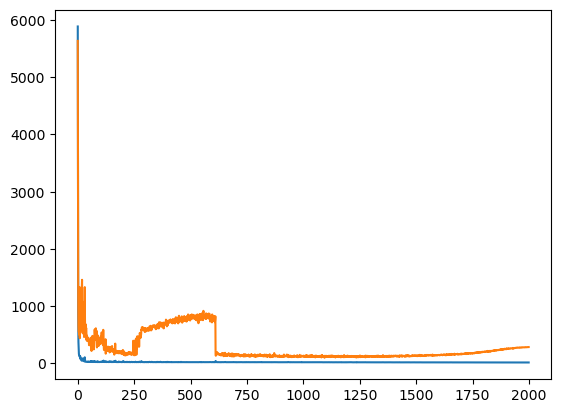

In [438]:
%autoreload

# Definitions
replica_number = 6
name = 'test'
model_folder = mkdir(f'pickles/committor_models')
save_folder = mkdir(f'{model_folder}/{name}')
pkl_save(f'{save_folder}/scaler.h5', scaler)

# Main loop
for num in np.arange(replica_number):

    # Run training and save the network
    network = free_energy_nn.RNNArchLSTM(size_input = train_dataset.descriptors[0].shape[-1],
                                         size_hidden = pow(2, 4),
                                         numb_RNN_layers = 2,
                                         size_output = 1,
                                         dropout = 0.0,
                                         device = torch.device('cuda'))

    network, optimizer, device, dtype = committor_nn.prepare_network(network,
                                                               lr=Parameters_dict['Learning_rate'],
                                                               optimizer=None,
                                                               cuda=True,
                                                               save_path='')

    train_losses, test_losses = free_energy_nn.train_RNN(network,
                                                 Parameters_dict['Epochs'],
                                                 optimizer,
                                                 train_dataloader,
                                                 test_dataloader,
                                                 device,
                                                 dtype,
                                                 verbose=True,
                                                 save_to=f'{save_folder}/{num}.h5')
    

    plt.plot(train_losses)
    plt.plot(test_losses)
    break

## Validation

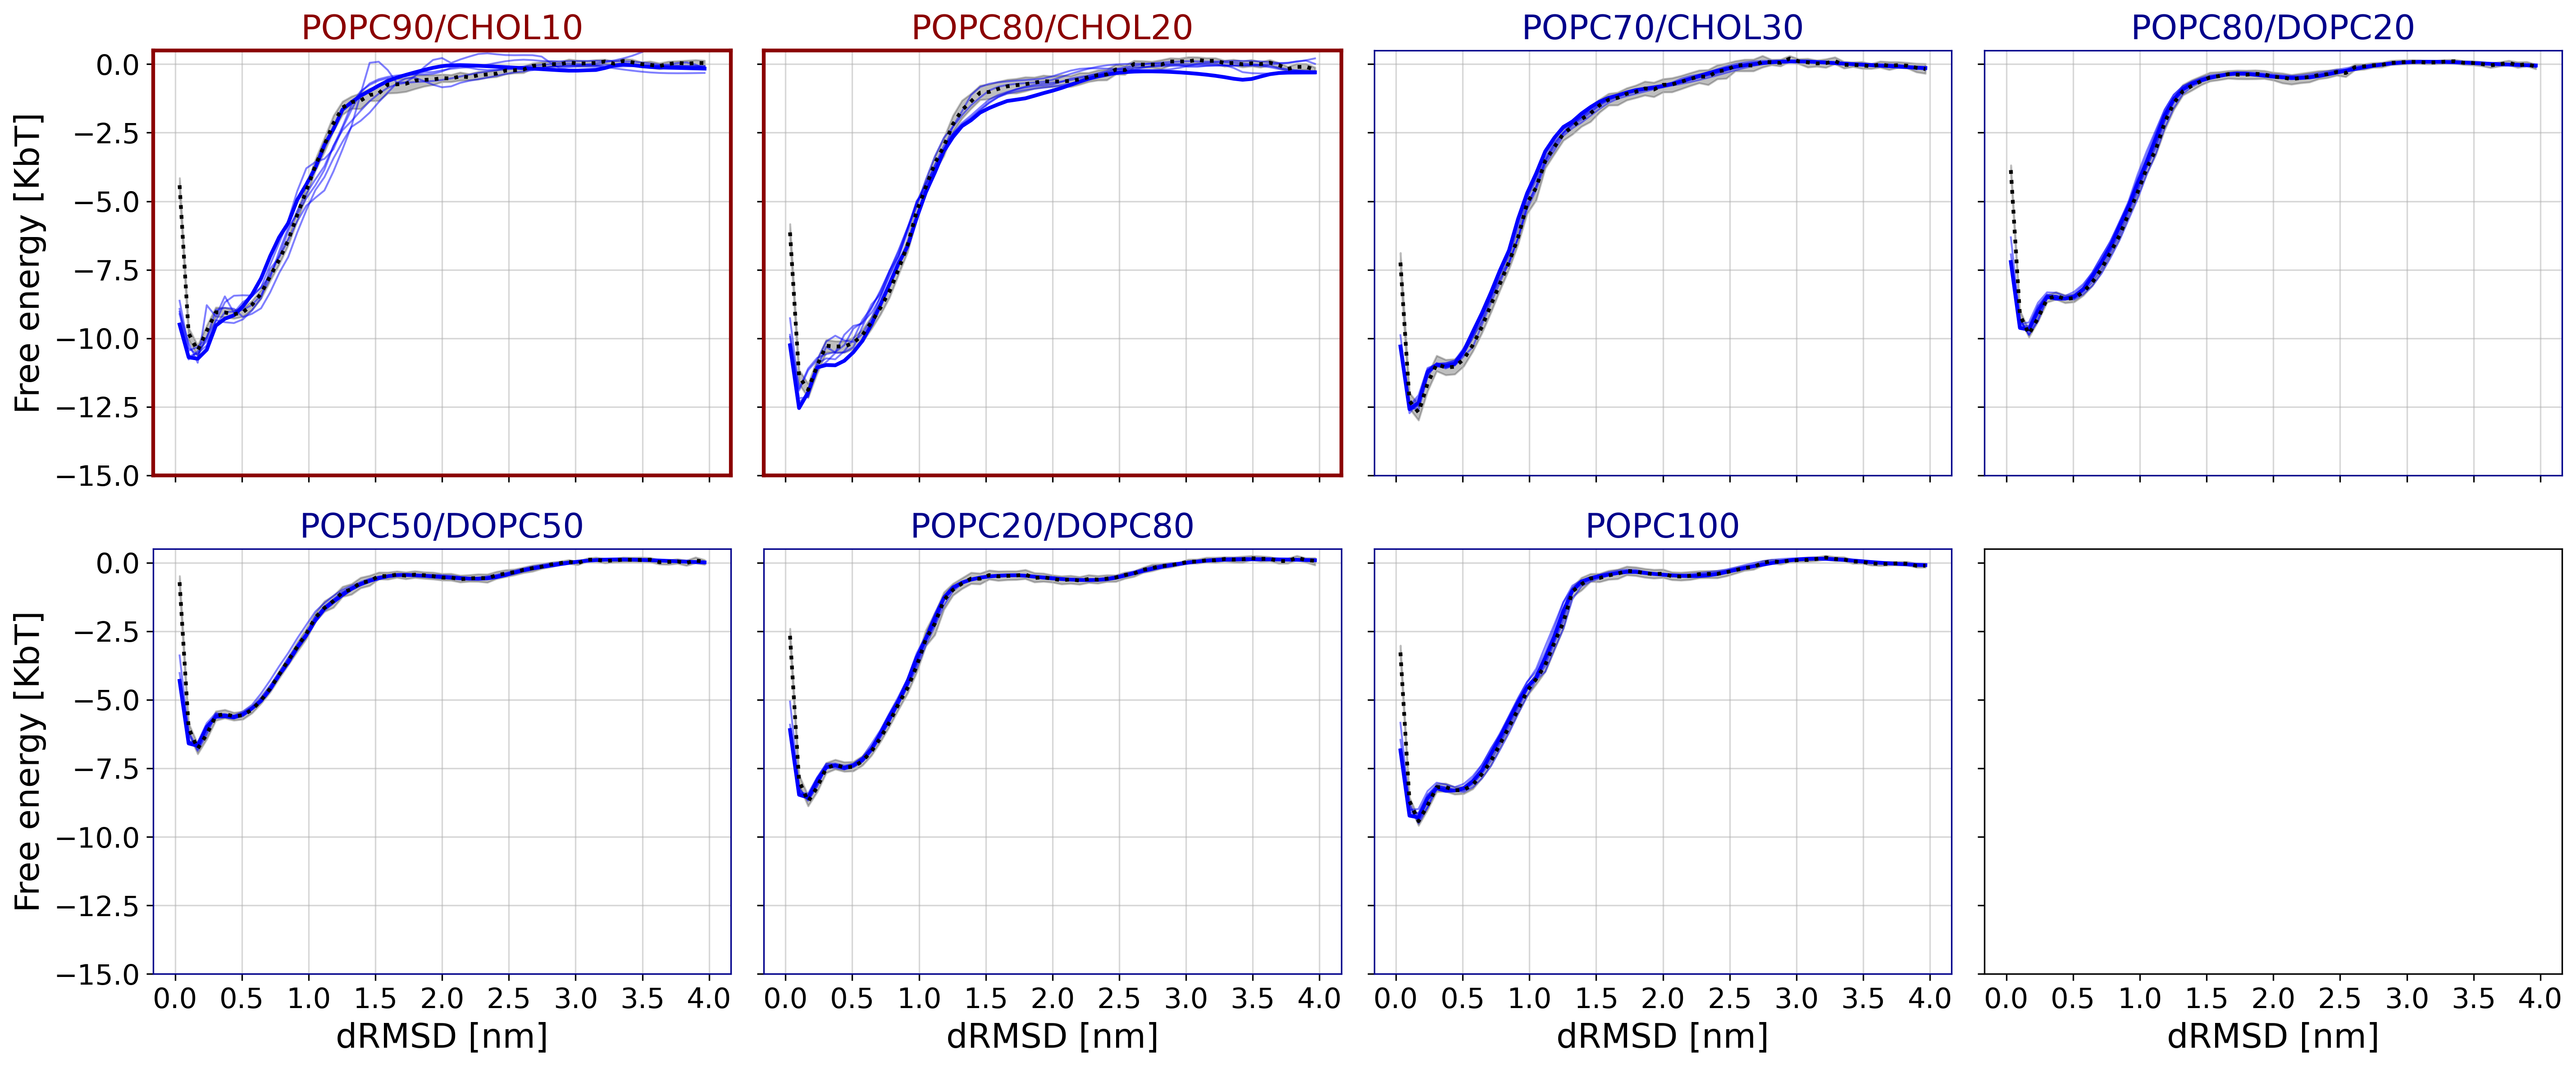

In [21]:
models = 'pickles/committor_models/fe_nn_no_CHOL10_CHOL20'

no_comp = compositions_test
membrane_compositions = sorted(compositions_training + compositions_test, key= lambda string: string.split('_')[-1])

fig, axes = plt.subplots(2, 4, figsize=(19, 8), dpi=300, sharey=True, sharex=True)
for index, target_membrane_composition in enumerate(membrane_compositions):
    
    name = '/'.join(target_membrane_composition.split('_'))
    # axis
    position1 = int(index/4.0)
    position2 = int(index%4.0)
    ax = axes[position1, position2]

    shift = '[0, 4]'
    bins = np.linspace(0, 4, 60)
    bins_c = (bins[:-1] + bins[1:])/2

    # define input parameter for nn
    composition_input = results_dict[target_membrane_composition][shift]
    input_array = composition_input['descriptors']
    results_array, error_min, error_max = composition_input['reference']
    scaler = pkl_load(f'{models}/scaler.h5')
    input_array = scaler.transform(input_array)
    
    for num, i in enumerate(sorted(glob.glob(f'{models}/?.h5'))):
        best_model = pkl_load(i)
        network = free_energy_nn.RNNArchLSTM(**best_model[0])
        network.load_state_dict(best_model[1])
        network.to('cpu')
        target_free_energy = free_energy_nn.evaluate(network, torch.tensor([input_array]))
        if num == 2:
            ax.plot(bins_c, target_free_energy,
                    linewidth=2, 
                     label='Neural network estimate',
                    color='blue')
        else:
            ax.plot(bins_c, target_free_energy,
                    linewidth=1, 
                     label='Neural network estimate',
                    color='blue',
                   alpha=0.5)
    ax.fill_between(bins_c,
                    error_min,
                    error_max,
                    alpha=0.25,
                    color='black')
    ax.plot(bins_c, results_array , color='black', linestyle=':', linewidth=2, 
             label='Target free energy')
    if position2 == 0 :
        ax.set_ylabel('Free energy [KbT]', fontsize=18)
    if membrane_compositions[index] in no_comp:
        ax.set_title(f'{name}',
                     fontsize=18, color='darkred')
        for spine in ax.spines.values():
            spine.set_linewidth(2.0)
            spine.set_edgecolor('darkred')
    else:
        ax.set_title(f'{name}',
                     fontsize=18, color='darkblue')
        for spine in ax.spines.values():
            spine.set_edgecolor('darkblue')
    ax.grid(alpha=0.5)
    ax.set_ylim(-15, 0.5)
    ax.set_xticks(np.arange(0, 4.1, 0.5))
    ax.tick_params(axis='both', which='major', labelsize=15)
if not len(membrane_compositions)%4 == 0:
    for index in np.arange(4):
        axes[int(len(membrane_compositions)/4), index].set_xlabel('dRMSD [nm]', fontsize=18)
        axes[int(len(membrane_compositions)/4), index].tick_params(axis='both', which='major', labelsize=15)
fig.tight_layout()

plt.savefig(f'plots/free_energy_nn_no_CHOL10_CHOL20.pdf', bbox_inches='tight')